In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

In [33]:
df = pd.read_csv('K_mean_Mall_Customers.csv')

In [34]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [35]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [36]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


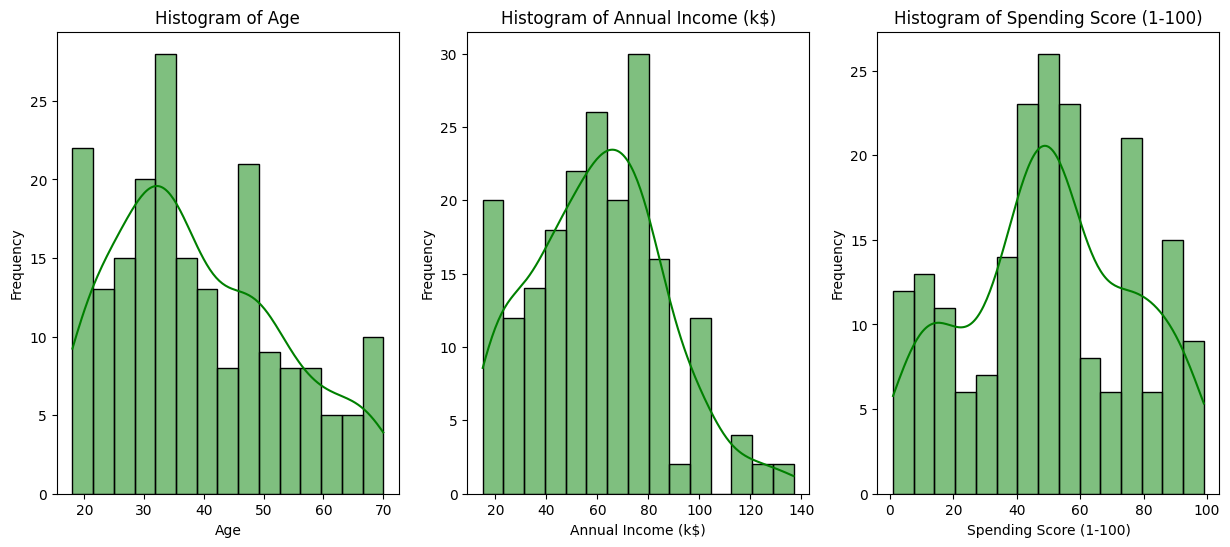

In [37]:
plt.figure(1, figsize=(15, 6))
i = 1
for x in["Age", "Annual Income (k$)", "Spending Score (1-100)"]:
    plt.subplot(1, 3, i)  #1 row, 3 columns, i iteration
    sns.histplot(df[x], bins=15,kde=True,color="g")
    plt.title("Histogram of {}".format(x))
    plt.xlabel(x)
    plt.ylabel("Frequency")
    i += 1
    
plt.show()

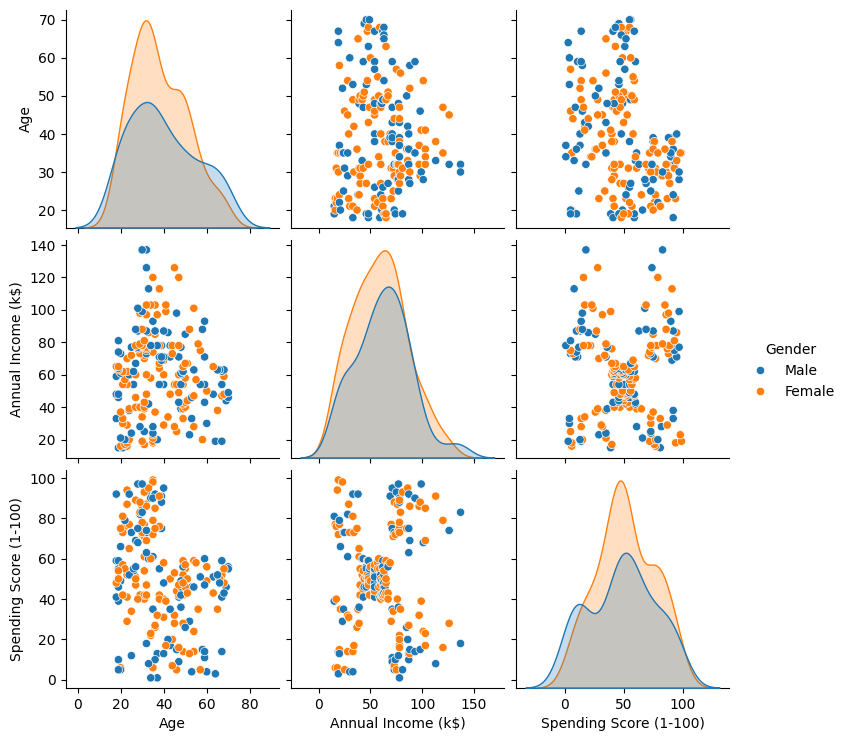

In [38]:
#pair plot 
sns.pairplot(df,vars = ["Age", "Annual Income (k$)", "Spending Score (1-100)"],hue = "Gender")
plt.show()

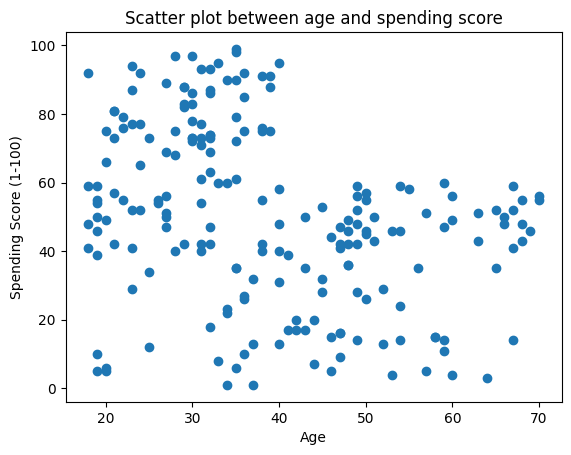

In [39]:
plt.scatter(df["Age"], df["Spending Score (1-100)"])
plt.title("Scatter plot between age and spending score")
plt.xlabel("Age")
plt.ylabel("Spending Score (1-100)")
plt.show()

In [40]:
X = df.drop(columns = ["CustomerID","Annual Income (k$)","Gender"], axis = 1)
s = StandardScaler()
scaled_X = s.fit_transform(X)

k_range = range(2, 15)
inertia = []
sil = []
for i in k_range:
    km = KMeans(n_clusters=i, #no.of cluster 
                init = "k-means++", #init means initilalization method for centroids kmean++ is a smart algorithm to choose 
                                    #the initial centroids for k-means clustering
                n_init = 10, #used to tell your computer how many times cluster will run (here 10 times with different centroid seeds points)
                max_iter = 300,#how many no. of iteration 
                tol=0.0001,#       
                random_state=111,    
                algorithm = "lloyd") #lloyd is the k-means algorithm   
    labels = km.fit_predict(scaled_X)
    inertia.append(km.inertia_) #inertia is the sum of squared distances of samples to their closest cluster center.
    sil.append(silhouette_score(scaled_X, labels)) # silhouette_score is a measure of how similar an object is to its own cluster compared to other clusters. It ranges from -1 to 1, where a higher value indicates that the object is well matched to its own cluster and poorly matched to neighboring clusters.

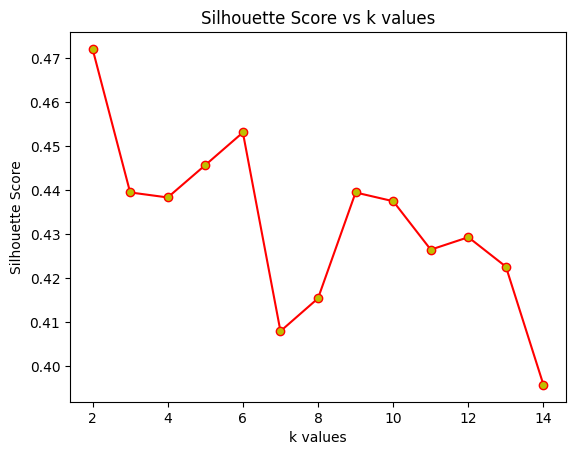

In [41]:
plt.title("Silhouette Score vs k values")
plt.plot(k_range, sil, marker="o",color="r",markerfacecolor="y")
plt.xlabel("k values")
plt.ylabel("Silhouette Score")
plt.show()

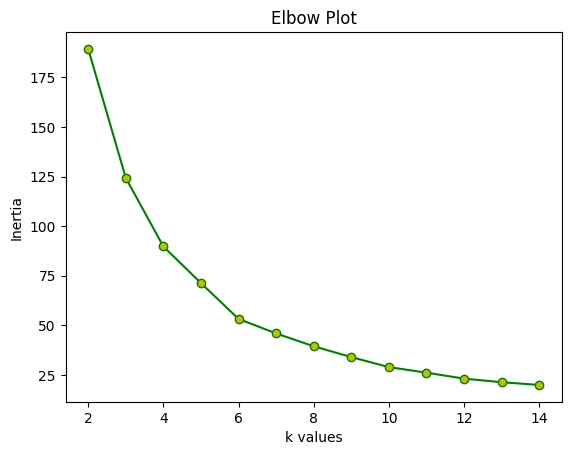

In [42]:
plt.title("Elbow Plot")
plt.plot(k_range, inertia, marker="o",color="g",markerfacecolor="y")
plt.xlabel("k values")
plt.ylabel("Inertia")
plt.show()

In [46]:
km = KMeans(n_clusters=6, #no.of cluster 
                init = "k-means++", #init means initilalization method for centroids kmean++ is a smart algorithm to choose 
                                    #the initial centroids for k-means clustering
                n_init = 10, #used to tell your computer how many times cluster will run (here 10 times with different centroid seeds points)
                max_iter = 300,#how many no. of iteration 
                tol=0.0001,#       
                random_state=111,    
                algorithm = "elkan") #lloyd is the k-means algorithm   
labels = km.fit_predict(scaled_X)

km.fit(scaled_X)
centroids = km.cluster_centers_

In [47]:
arr_X = X.values
h = 0.02
xin, xmax = arr_X[:, 0].min() - 1, arr_X[:, 0].max() + 1
yin, ymax = arr_X[:, 1].min() - 1, arr_X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(xin, xmax, h), np.arange(yin, ymax, h))
Z = km.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


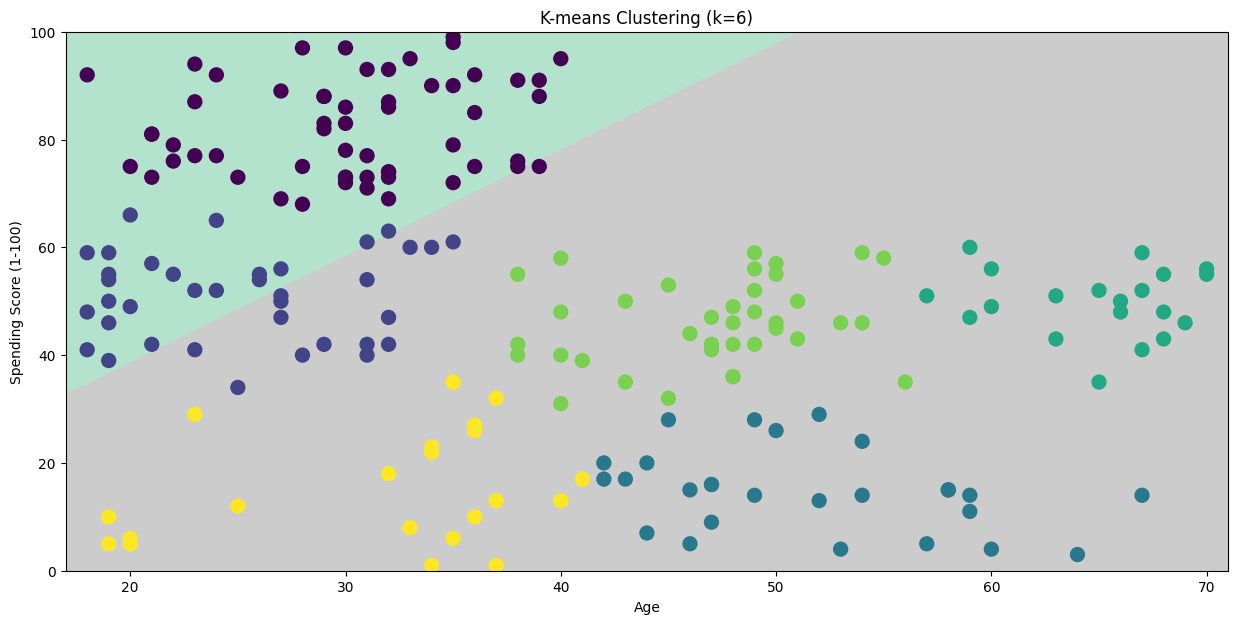

In [49]:
plt.figure(1, figsize=(15, 7))
plt.clf()
Z = Z.reshape(xx.shape)
plt.imshow(Z, interpolation="nearest", extent=(xx.min(), xx.max(), yy.min(), yy.max()), cmap=plt.cm.Pastel2, aspect="auto", origin="lower")
plt.scatter(x = 'Age', y = 'Spending Score (1-100)', data = df, c=labels, s =100)
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c="black", alpha=0.5, marker="X") #centroid points
plt.title("K-means Clustering (k=6)")
plt.xlabel("Age")
plt.ylabel("Spending Score (1-100)")    
plt.xlim(xin, xmax)
plt.ylim(yin, ymax) 
plt.show()